## Airline Passenger Forecasting (Havayolu Yolcu Sayısı Tahmini)

In [1]:
#
# Bir havacılık firmasının geçmiş yıllara ait taşıdığı yolcu sayıları üzerinden
# "Gelecek dönemlerde kaç yolcu taşıyacağız?" sorusuna yanıt arıyoruz. 
# Bu problem için az önce öğrendiğimiz Yumuşatma (Smoothing) ve İstatistiksel
# Analiz (ARIMA & SARIMA) yöntemlerinin tam donanımlı bir kıyaslamasını yapacağız!

import itertools
import warnings
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.arima.model import ARIMA  # Not: statsmodels>=0.12 ile eski "arima_model" modülü kaldırıldığı için içe aktarma yolu güncellendi.
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# Eski metodların verdiği depreceated uyarılarını ekrandan siliyoruz.
warnings.filterwarnings('ignore')

## Verinin Okunup Görselleştirilmesi

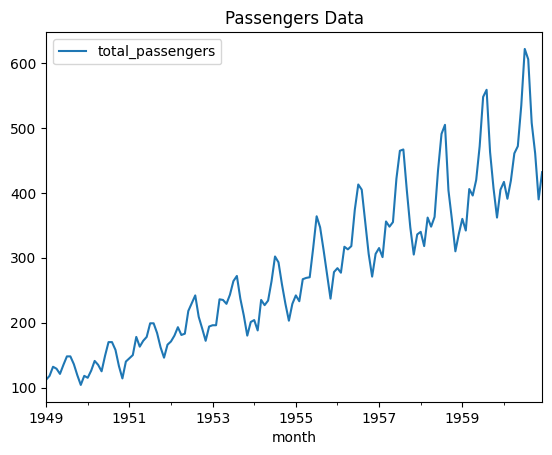

In [2]:
# Verisetimizi lokal dizinimizdeki 'time_series_datasets' klasöründen çağırıyoruz.
# index_col='month' diyerek ayların olduğu sütunu index yapıyor,
# parse_dates=True ile de bu ayların string (yazı) değil "Tarih Formatı (Datetime)" olduğunu belirtiyoruz.
df = pd.read_csv('../time_series_datasets/airline-passengers.csv', index_col='month', parse_dates=True)

df.shape # Kaç satır kaç sütun verimiz var kontrolü
df.head() # İlk 5 satır

# Yolcuların gidişatını (Trend) ve mevsimsellik zikzaklarını görmek için ilk çizimimiz:
df[['total_passengers']].plot(title='Passengers Data')
plt.show()

df.index # indexlerin tipini teyit edelim (DatetimeIndex olması gerek).

# Zaman serisi objemizde bir periyot sabitlemesi yapıyoruz: 
# MS = Month Start. Pandas'a "bu verilerin aydan aya olduğunu biliyorsun, değil mi?" demenin kısayoludur.
df.index.freq = "MS" 

# Tüm datamız 144 ay uzunluğunda (12 yıl). Modelin sınanması için Train-Test ayrımı (Holdout) yapalım:
train = df[:120]  # İlk 10 yıllık (120 ay) veriyi modeli EĞİTMEK için ayırdık.
test = df[120:]   # Kalan 2 yıl (24 ay) ise modelin sınav kağıdı olacak!

## Single Exponential Smoothing (SES - Seviye Odaklı Düzeltme)

alpha: 0.01 mae: 225.5863
alpha: 0.11 mae: 82.528
alpha: 0.21 mae: 82.8979
alpha: 0.31 mae: 89.8377
alpha: 0.41 mae: 99.0585
alpha: 0.51 mae: 107.5558
alpha: 0.61 mae: 113.7514
alpha: 0.71 mae: 117.2224
alpha: 0.81 mae: 118.1776
alpha: 0.91 mae: 117.2438
best_alpha: 0.11 best_mae: 82.528


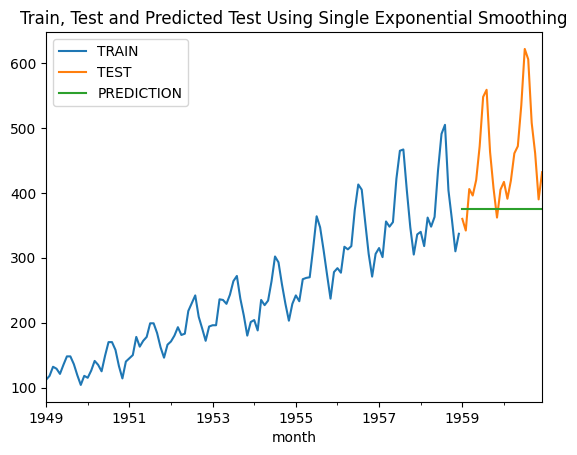

In [3]:
# SES sadece serinin durağan ve trend/mevsimsellik içermeyen düz çizgisini kopyalamaya çalışır.
# (Havayolu verisinde trend bariz olduğu için muhtemelen çuvallayacak göreceğiz!)

def ses_optimizer(train, alphas, step=48):
    best_alpha, best_mae = None, float("inf")
    for alpha in alphas:
        # Train üzerinde her alpha ihtimalini fit et.
        ses_model = SimpleExpSmoothing(train).fit(smoothing_level=alpha)
        y_pred = ses_model.forecast(step) # Belirtilen adım kadar tahmine koş!
        mae = mean_absolute_error(test, y_pred) # Rekor Hata Puanı (MAE) kontrolü:
        if mae < best_mae:
            best_alpha, best_mae = alpha, mae
        print("alpha:", round(alpha, 2), "mae:", round(mae, 4))
    print("best_alpha:", round(best_alpha, 2), "best_mae:", round(best_mae, 4))
    return best_alpha, best_mae

alphas = np.arange(0.01, 1, 0.10) # 0.01'den başlayan alpha seviyeleri

# Optimizasyonu 24 adımlık test dönemi tahminine göre koşturuyoruz.
best_alpha, best_mae = ses_optimizer(train, alphas, step=24)
# (Çıktıya göre en iyi alpha: 0.11 iken ulaşılan MAE: 82.528 civarı oldu)

# Model kuruldu
ses_model = SimpleExpSmoothing(train).fit(smoothing_level=best_alpha)
y_pred = ses_model.forecast(24) # Tahminler çekildi.

# Sıkça çizim yapacağımız için işleri kısaltan bir çizim fonksiyonu yazıyoruz:
def plot_prediction(y_pred, label):
    train["total_passengers"].plot(legend=True, label="TRAIN")
    test["total_passengers"].plot(legend=True, label="TEST")
    y_pred.plot(legend=True, label="PREDICTION")
    plt.title("Train, Test and Predicted Test Using "+label)
    plt.show()

# Grafikte SES'in "Trend" algısı olmadığı için düz bir doğru çektiğini apaçık görebiliriz. Düz çizgi!
plot_prediction(y_pred, "Single Exponential Smoothing")

## Double Exponential Smoothing (DES - Seviye + Trend Odaklı)

alpha: 0.01 beta: 0.01 mae: 54.9512
alpha: 0.01 beta: 0.11 mae: 54.1036
alpha: 0.01 beta: 0.21 mae: 55.5569
alpha: 0.01 beta: 0.31 mae: 57.3247
alpha: 0.01 beta: 0.41 mae: 57.7931
alpha: 0.01 beta: 0.51 mae: 57.9968


alpha: 0.01 beta: 0.61 mae: 57.9637
alpha: 0.01 beta: 0.71 mae: 57.5636
alpha: 0.01 beta: 0.81 mae: 57.3334
alpha: 0.01 beta: 0.91 mae: 57.8984
alpha: 0.11 beta: 0.01 mae: 55.0309
alpha: 0.11 beta: 0.11 mae: 58.4728
alpha: 0.11 beta: 0.21 mae: 69.6339
alpha: 0.11 beta: 0.31 mae: 72.555
alpha: 0.11 beta: 0.41 mae: 78.8168
alpha: 0.11 beta: 0.51 mae: 81.996
alpha: 0.11 beta: 0.61 mae: 77.2262
alpha: 0.11 beta: 0.71 mae: 71.5042
alpha: 0.11 beta: 0.81 mae: 69.0258
alpha: 0.11 beta: 0.91 mae: 67.8408
alpha: 0.21 beta: 0.01 mae: 57.1824
alpha: 0.21 beta: 0.11 mae: 74.992
alpha: 0.21 beta: 0.21 mae: 95.9492
alpha: 0.21 beta: 0.31 mae: 115.3164
alpha: 0.21 beta: 0.41 mae: 139.4303
alpha: 0.21 beta: 0.51 mae: 178.3759
alpha: 0.21 beta: 0.61 mae: 243.4543
alpha: 0.21 beta: 0.71 mae: 345.299
alpha: 0.21 beta: 0.81 mae: 489.8453


alpha: 0.21 beta: 0.91 mae: 675.8334
alpha: 0.31 beta: 0.01 mae: 65.3308
alpha: 0.31 beta: 0.11 mae: 102.5159
alpha: 0.31 beta: 0.21 mae: 150.3694
alpha: 0.31 beta: 0.31 mae: 213.3573
alpha: 0.31 beta: 0.41 mae: 307.2251


alpha: 0.31 beta: 0.51 mae: 441.9762
alpha: 0.31 beta: 0.61 mae: 608.1276
alpha: 0.31 beta: 0.71 mae: 778.9847
alpha: 0.31 beta: 0.81 mae: 921.2448
alpha: 0.31 beta: 0.91 mae: 1013.8071
alpha: 0.41 beta: 0.01 mae: 74.6629
alpha: 0.41 beta: 0.11 mae: 134.9652
alpha: 0.41 beta: 0.21 mae: 214.0271
alpha: 0.41 beta: 0.31 mae: 321.1816
alpha: 0.41 beta: 0.41 mae: 457.7845
alpha: 0.41 beta: 0.51 mae: 604.528
alpha: 0.41 beta: 0.61 mae: 731.2542
alpha: 0.41 beta: 0.71 mae: 816.4681
alpha: 0.41 beta: 0.81 mae: 856.8799
alpha: 0.41 beta: 0.91 mae: 861.1779
alpha: 0.51 beta: 0.01 mae: 83.8759
alpha: 0.51 beta: 0.11 mae: 162.7106
alpha: 0.51 beta: 0.21 mae: 262.9556
alpha: 0.51 beta: 0.31 mae: 384.168
alpha: 0.51 beta: 0.41 mae: 510.8847
alpha: 0.51 beta: 0.51 mae: 615.718
alpha: 0.51 beta: 0.61 mae: 679.6289
alpha: 0.51 beta: 0.71 mae: 699.5586


alpha: 0.51 beta: 0.81 mae: 681.8415
alpha: 0.51 beta: 0.91 mae: 633.8713
alpha: 0.61 beta: 0.01 mae: 91.1493
alpha: 0.61 beta: 0.11 mae: 180.5749
alpha: 0.61 beta: 0.21 mae: 286.5276
alpha: 0.61 beta: 0.31 mae: 398.7627


alpha: 0.61 beta: 0.41 mae: 494.8066
alpha: 0.61 beta: 0.51 mae: 552.8904
alpha: 0.61 beta: 0.61 mae: 565.2675
alpha: 0.61 beta: 0.71 mae: 535.41
alpha: 0.61 beta: 0.81 mae: 470.4302
alpha: 0.61 beta: 0.91 mae: 377.2283
alpha: 0.71 beta: 0.01 mae: 95.5898
alpha: 0.71 beta: 0.11 mae: 188.0569
alpha: 0.71 beta: 0.21 mae: 289.0405
alpha: 0.71 beta: 0.31 mae: 381.6533
alpha: 0.71 beta: 0.41 mae: 443.8336
alpha: 0.71 beta: 0.51 mae: 461.4037
alpha: 0.71 beta: 0.61 mae: 433.7736
alpha: 0.71 beta: 0.71 mae: 368.1872
alpha: 0.71 beta: 0.81 mae: 274.2863
alpha: 0.71 beta: 0.91 mae: 162.1223
alpha: 0.81 beta: 0.01 mae: 97.025
alpha: 0.81 beta: 0.11 mae: 187.5378
alpha: 0.81 beta: 0.21 mae: 277.7663


alpha: 0.81 beta: 0.31 mae: 348.1264
alpha: 0.81 beta: 0.41 mae: 380.2822
alpha: 0.81 beta: 0.51 mae: 367.0635
alpha: 0.81 beta: 0.61 mae: 313.3918
alpha: 0.81 beta: 0.71 mae: 230.0239
alpha: 0.81 beta: 0.81 mae: 129.043
alpha: 0.81 beta: 0.91 mae: 60.7209
alpha: 0.91 beta: 0.01 mae: 96.1602
alpha: 0.91 beta: 0.11 mae: 181.6748
alpha: 0.91 beta: 0.21 mae: 258.9646
alpha: 0.91 beta: 0.31 mae: 308.5961
alpha: 0.91 beta: 0.41 mae: 317.1132
alpha: 0.91 beta: 0.51 mae: 283.2875


alpha: 0.91 beta: 0.61 mae: 216.0383
alpha: 0.91 beta: 0.71 mae: 127.9546
alpha: 0.91 beta: 0.81 mae: 59.6742
alpha: 0.91 beta: 0.91 mae: 94.305
best_alpha: 0.01 best_beta: 0.11 best_mae: 54.1036


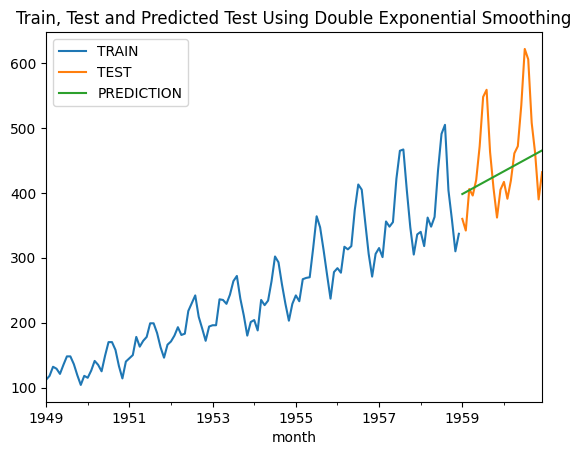

In [4]:
# Madem havacılıkta yükselen bir trend var. (Bilet alanlar yıllara göre artıyor).
# O zaman SES değil, Trend parametresi olan (Beta) Çifte Düzeltme'ye bakalım!

def des_optimizer(train, alphas, betas, step=48):
    best_alpha, best_beta, best_mae = None, None, float("inf")
    for alpha in alphas:
        for beta in betas: # Alpha ve Beta için 2 boyutlu iç içe optimizasyon araması.
            des_model = ExponentialSmoothing(train, trend="add").fit(smoothing_level=alpha, smoothing_slope=beta)
            y_pred = des_model.forecast(step)
            mae = mean_absolute_error(test, y_pred)
            if mae < best_mae:
                best_alpha, best_beta, best_mae = alpha, beta, mae
            print("alpha:", round(alpha, 2), "beta:", round(beta, 2), "mae:", round(mae, 4))
    print("best_alpha:", round(best_alpha, 2), "best_beta:", round(best_beta, 2), "best_mae:", round(best_mae, 4))
    return best_alpha, best_beta, best_mae

alphas = np.arange(0.01, 1, 0.10)
betas = np.arange(0.01, 1, 0.10)

best_alpha, best_beta, best_mae = des_optimizer(train, alphas, betas, step=24)
# Optimizasyon sonrası best_alpha: 0.01 best_beta: 0.11 best_mae: 54.1036 (SES'teki 82 hatadan 54'e kadar düştük!)

des_model = ExponentialSmoothing(train, trend="add").fit(smoothing_level=best_alpha,
                                                         smoothing_slope=best_beta)
y_pred = des_model.forecast(24)

# Grafikte bu kez dümdüz yatay çizgi yerine "yukarı tırmanan bir doğru çizgisi" göreceğiz. Ama Melesef Mevsimsellik zikzaklarını algılayamadı.
plot_prediction(y_pred, "Double Exponential Smoothing")

## Triple Exponential Smoothing (Holt-Winters) (Seviye + Trend + MEVSİMSELLİK)

[np.float64(0.1), np.float64(0.1), np.float64(0.1), 36.83]
[np.float64(0.1), np.float64(0.1), np.float64(0.3), 34.88]
[np.float64(0.1), np.float64(0.1), np.float64(0.5), 35.91]
[np.float64(0.1), np.float64(0.1), np.float64(0.7), 38.72]
[np.float64(0.1), np.float64(0.1), np.float64(0.9), 42.55]
[np.float64(0.1), np.float64(0.3), np.float64(0.1), 53.96]
[np.float64(0.1), np.float64(0.3), np.float64(0.3), 53.0]


[np.float64(0.1), np.float64(0.3), np.float64(0.5), 56.98]
[np.float64(0.1), np.float64(0.3), np.float64(0.7), 61.38]
[np.float64(0.1), np.float64(0.3), np.float64(0.9), 67.17]
[np.float64(0.1), np.float64(0.5), np.float64(0.1), 56.76]


[np.float64(0.1), np.float64(0.5), np.float64(0.3), 51.72]
[np.float64(0.1), np.float64(0.5), np.float64(0.5), 53.39]
[np.float64(0.1), np.float64(0.5), np.float64(0.7), 60.08]
[np.float64(0.1), np.float64(0.5), np.float64(0.9), 79.29]
[np.float64(0.1), np.float64(0.7), np.float64(0.1), 34.04]
[np.float64(0.1), np.float64(0.7), np.float64(0.3), 25.93]
[np.float64(0.1), np.float64(0.7), np.float64(0.5), 27.81]


[np.float64(0.1), np.float64(0.7), np.float64(0.7), 27.91]
[np.float64(0.1), np.float64(0.7), np.float64(0.9), 38.32]
[np.float64(0.1), np.float64(0.9), np.float64(0.1), 26.87]
[np.float64(0.1), np.float64(0.9), np.float64(0.3), 25.32]
[np.float64(0.1), np.float64(0.9), np.float64(0.5), 53.88]
[np.float64(0.1), np.float64(0.9), np.float64(0.7), 38.38]


[np.float64(0.1), np.float64(0.9), np.float64(0.9), 17.77]
[np.float64(0.3), np.float64(0.1), np.float64(0.1), 54.54]
[np.float64(0.3), np.float64(0.1), np.float64(0.3), 38.34]
[np.float64(0.3), np.float64(0.1), np.float64(0.5), 31.57]
[np.float64(0.3), np.float64(0.1), np.float64(0.7), 30.99]


...

[np.float64(0.9), np.float64(0.3), np.float64(0.9), 125.11]
[np.float64(0.9), np.float64(0.5), np.float64(0.1), 245.77]
[np.float64(0.9), np.float64(0.5), np.float64(0.3), 301.42]
[np.float64(0.9), np.float64(0.5), np.float64(0.5), 280.73]
[np.float64(0.9), np.float64(0.5), np.float64(0.7), 240.08]


[np.float64(0.9), np.float64(0.5), np.float64(0.9), 182.97]
[np.float64(0.9), np.float64(0.7), np.float64(0.1), 218.45]
[np.float64(0.9), np.float64(0.7), np.float64(0.3), 299.87]
[np.float64(0.9), np.float64(0.7), np.float64(0.5), 298.5]


[np.float64(0.9), np.float64(0.7), np.float64(0.7), 241.07]
[np.float64(0.9), np.float64(0.7), np.float64(0.9), 233.9]
[np.float64(0.9), np.float64(0.9), np.float64(0.1), 170.18]


[np.float64(0.9), np.float64(0.9), np.float64(0.3), 261.35]
[np.float64(0.9), np.float64(0.9), np.float64(0.5), 284.26]
[np.float64(0.9), np.float64(0.9), np.float64(0.7), 216.67]


[np.float64(0.9), np.float64(0.9), np.float64(0.9), 263.57]
best_alpha: 0.3 best_beta: 0.3 best_gamma: 0.5 best_mae: 11.9947


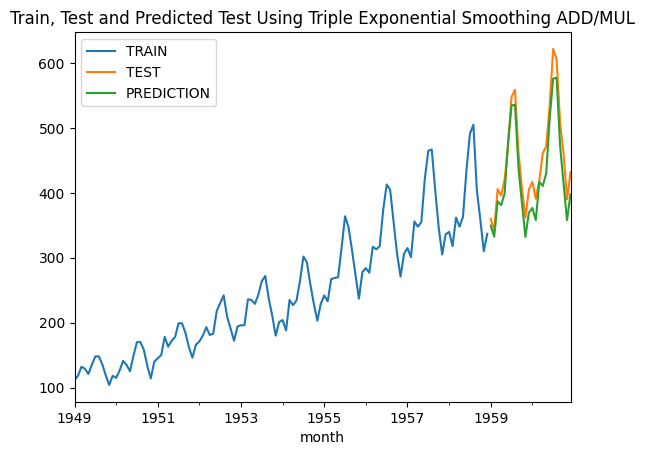

In [5]:
# DES yukarı doğru eğilen trendi anladı ama yazın artan, kışın azalan yolcu sayısını kavrayamadı.
# Holt-Winters tam da bu noktada devreye girer.

def tes_optimizer(train, abg, step=48):
    best_alpha, best_beta, best_gamma, best_mae = None, None, None, float("inf") # Gamma mevsimsellik ağırlığıdır!
    for comb in abg: # Kombinasyon demetindeki 3'lü parametre gruplarını döner
        tes_model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).\
            fit(smoothing_level=comb[0], smoothing_slope=comb[1], smoothing_seasonal=comb[2]) # Dönem olarak aylık=12 ay girdik.
        y_pred = tes_model.forecast(step)
        mae = mean_absolute_error(test, y_pred)
        if mae < best_mae:
            best_alpha, best_beta, best_gamma, best_mae = comb[0], comb[1], comb[2], mae
        print([round(comb[0], 2), round(comb[1], 2), round(comb[2], 2), round(mae, 2)])

    print("best_alpha:", round(best_alpha, 2), "best_beta:", round(best_beta, 2), "best_gamma:", round(best_gamma, 2),
          "best_mae:", round(best_mae, 4))

    return best_alpha, best_beta, best_gamma, best_mae

alphas = betas = gammas = np.arange(0.10, 1, 0.20) # Aralık adım sayısını biraz genişletip hızlandırdık.
abg = list(itertools.product(alphas, betas, gammas))

best_alpha, best_beta, best_gamma, best_mae = tes_optimizer(train, abg, step=24)
# Optimizasyon Sonucu: best_alpha: 0.3 best_beta: 0.3 best_gamma: 0.5 best_mae: 11.9947 ! (54 Küsür hatadan 11'e muazzam bir düşüş yakaladık)

# DİKKAT! Yukarıda 'add' (toplamsal) olarak denemiştik. Ancak havayolu verisindeki zikzakların boyu yıllar geçtikçe büyüyor
# Yıllar ilerledikçe varyans artıyorsa, model tipi Toplamsal değil Çarpımsal'dır! (Multiplicative - 'mul')
tes_model = ExponentialSmoothing(train, trend="mul", seasonal="mul", seasonal_periods=12).\
            fit(smoothing_level=best_alpha, smoothing_slope=best_beta, smoothing_seasonal=best_gamma)

y_pred = tes_model.forecast(24)

# Tahmini bir de grafikte görelim, zikzaklar muhteşem örtüşmüş durumda:
plot_prediction(y_pred, "Triple Exponential Smoothing ADD/MUL")

## ARIMA(p, d, q): (Sadece Trend Varsa ARIMA)

Best ARIMANone AIC=inf


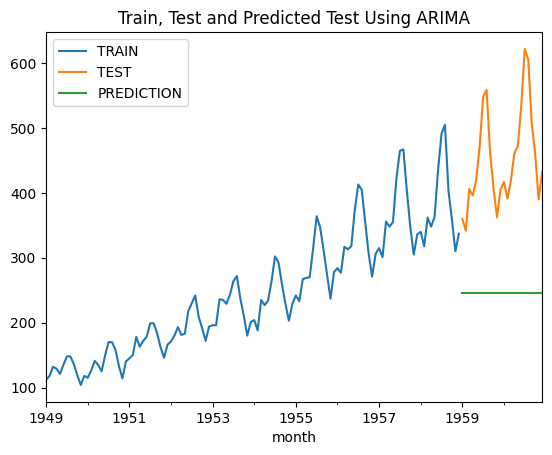

In [6]:
# İstatistiksel tarafa döndüğümüzde, ARIMA da mevsimsellik kavrayamaz. Eğik bir doğru çizecek.

p = d = q = range(0, 4)
pdq = list(itertools.product(p, d, q))


def arima_optimizer_aic(train, orders):
    best_aic, best_params = float("inf"), None
    for order in orders:
        try:
            arma_model_result = ARIMA(train, order).fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.
            aic = arma_model_result.aic # AIC bazlı başarı. (Düşük olması iyi)
            if aic < best_aic:
                best_aic, best_params = aic, order
            print('ARIMA%s AIC=%.2f' % (order, aic))
        except:
            continue
    print('Best ARIMA%s AIC=%.2f' % (best_params, best_aic))
    return best_params

best_params_aic = arima_optimizer_aic(train, pdq)

arima_model = ARIMA(train, best_params_aic).fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.
y_pred = arima_model.forecast(24)  # Not: yeni ARIMA API'sinde .forecast() dogrudan tahmin dizisini dondurur (eski API'de [0] gerekiyordu).
mean_absolute_error(test, y_pred)
# 51.1806294123169 (Tıpkı Double Exponential Smoothing gibi, mevsimsellik bulamayıp bocaladı!)


plot_prediction(pd.Series(y_pred, index=test.index), "ARIMA")

## SARIMA (Hem Trend Hem Mevsimsellik varsa SARIMA)

SARIMA(0, 0, 0)x(0, 0, 0, 12)12 - AIC:1680.2792351899682


SARIMA(0, 0, 0)x(0, 0, 1, 12)12 - AIC:1557.6320514855797
SARIMA(0, 0, 0)x(0, 1, 0, 12)12 - AIC:1060.4792883429307
SARIMA(0, 0, 0)x(0, 1, 1, 12)12 - AIC:1014.0696747520233


SARIMA(0, 0, 0)x(1, 0, 0, 12)12 - AIC:1231.9865853920926


SARIMA(0, 0, 0)x(1, 0, 1, 12)12 - AIC:1185.3010979097196
SARIMA(0, 0, 0)x(1, 1, 0, 12)12 - AIC:969.3781382611996


SARIMA(0, 0, 0)x(1, 1, 1, 12)12 - AIC:951.6114035277263
SARIMA(0, 0, 1)x(0, 0, 0, 12)12 - AIC:1524.362085340369
SARIMA(0, 0, 1)x(0, 0, 1, 12)12 - AIC:1403.5942349230986


...

SARIMA(1, 1, 0)x(1, 1, 1, 12)12 - AIC:806.0045298566731
SARIMA(1, 1, 1)x(0, 0, 0, 12)12 - AIC:1125.4285934222269


SARIMA(1, 1, 1)x(0, 0, 1, 12)12 - AIC:1047.4625749142192
SARIMA(1, 1, 1)x(0, 1, 0, 12)12 - AIC:804.813334828804


SARIMA(1, 1, 1)x(0, 1, 1, 12)12 - AIC:806.5701461103582
SARIMA(1, 1, 1)x(1, 0, 0, 12)12 - AIC:924.5502293258702


SARIMA(1, 1, 1)x(1, 0, 1, 12)12 - AIC:926.3624606318251
SARIMA(1, 1, 1)x(1, 1, 0, 12)12 - AIC:806.5003437988488


SARIMA(1, 1, 1)x(1, 1, 1, 12)12 - AIC:807.6603076291924
SARIMA(1, 1, 0)x(0, 1, 0, 12)12 - AIC:803.2812826904047


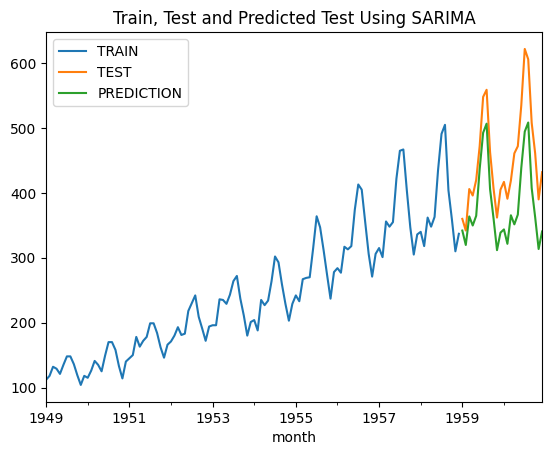

In [7]:
# Havayolu serisindeki o coşkunluğu ve devinimi anca SARIMA sökebilir.

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))] # Çarpı 12 Ay yapısıyla periyotları diz.


def sarima_optimizer_aic(train, pdq, seasonal_pdq):
    # Optimizasyon fonksiyonu (AIC Metoduyla)
    best_aic, best_order, best_seasonal_order = float("inf"), float("inf"), None
    for param in pdq:
        for param_seasonal in seasonal_pdq:
            try:
                sarimax_model = SARIMAX(train, order=param, seasonal_order=param_seasonal)
                results = sarimax_model.fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.
                aic = results.aic
                if aic < best_aic:
                    best_aic, best_order, best_seasonal_order = aic, param, param_seasonal
                print('SARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, aic))
            except:
                continue
    print('SARIMA{}x{}12 - AIC:{}'.format(best_order, best_seasonal_order, best_aic))
    return best_order, best_seasonal_order

# Parametreleri al
best_order, best_seasonal_order = sarima_optimizer_aic(train, pdq, seasonal_pdq)

model = SARIMAX(train, order=best_order, seasonal_order=best_seasonal_order)
sarima_final_model = model.fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.
y_pred_test = sarima_final_model.get_forecast(steps=24)

y_pred = y_pred_test.predicted_mean
mean_absolute_error(test, y_pred)
# Çıkan MAE: 68.57726545235921 (Biraz beklenenlerin altında!) Neden? AIC metrik olarak bazen MAE'de beklenen uçuşa geçemeyebiliyor.

plot_prediction(pd.Series(y_pred, index=test.index), "SARIMA")

## SARIMA için İnanılmaz BONUS: MAE Optimizasyonu

SARIMA(0, 0, 0)x(0, 0, 0, 12)12 - MAE:452.25
SARIMA(0, 0, 0)x(0, 0, 1, 12)12 - MAE:367.2095453687766
SARIMA(0, 0, 0)x(0, 1, 0, 12)12 - MAE:71.25


SARIMA(0, 0, 0)x(0, 1, 1, 12)12 - MAE:72.62972637021421
SARIMA(0, 0, 0)x(1, 0, 0, 12)12 - MAE:74.93610874818064


SARIMA(0, 0, 0)x(1, 0, 1, 12)12 - MAE:76.7970670435654
SARIMA(0, 0, 0)x(1, 1, 0, 12)12 - MAE:58.59973876847793


SARIMA(0, 0, 0)x(1, 1, 1, 12)12 - MAE:30.63755062891038
SARIMA(0, 0, 1)x(0, 0, 0, 12)12 - MAE:442.67323632604825


SARIMA(0, 0, 1)x(0, 0, 1, 12)12 - MAE:356.2897856522809
SARIMA(0, 0, 1)x(0, 1, 0, 12)12 - MAE:70.49252848495121


...

SARIMA(1, 1, 0)x(1, 1, 1, 12)12 - MAE:67.06498565079444
SARIMA(1, 1, 1)x(0, 0, 0, 12)12 - MAE:93.90498943280373


SARIMA(1, 1, 1)x(0, 0, 1, 12)12 - MAE:113.40777197924791
SARIMA(1, 1, 1)x(0, 1, 0, 12)12 - MAE:69.80282899605527
SARIMA(1, 1, 1)x(0, 1, 1, 12)12 - MAE:68.34977126359782


SARIMA(1, 1, 1)x(1, 0, 0, 12)12 - MAE:73.46696653183402


SARIMA(1, 1, 1)x(1, 0, 1, 12)12 - MAE:71.98883591756517
SARIMA(1, 1, 1)x(1, 1, 0, 12)12 - MAE:67.92901816365548


SARIMA(1, 1, 1)x(1, 1, 1, 12)12 - MAE:67.58764545199155
SARIMA(0, 0, 0)x(1, 1, 1, 12)12 - MAE:30.63755062891038


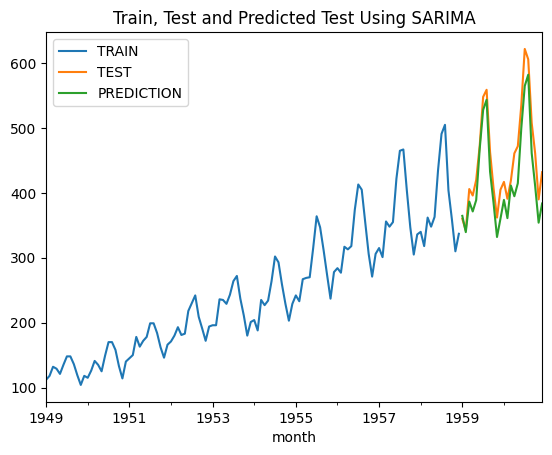

1961-01-01    450.286321
1961-02-01    429.302017
1961-03-01    475.721723
1961-04-01    502.017584
1961-05-01    516.825600
1961-06-01    579.037220
Freq: MS, dtype: float64

In [8]:
# Eğer AIC ile SARIMA modelimiz Holt-Winters'a yanaşamadıysa, bir de "Hata'yı baz alarak paramatre seç" diyebilmekteyiz.

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

def sarima_optimizer_mae(train, pdq, seasonal_pdq):
    best_mae, best_order, best_seasonal_order = float("inf"), float("inf"), None

    for param in pdq:
        for param_seasonal in seasonal_pdq:
            try:
                model = SARIMAX(train, order=param, seasonal_order=param_seasonal)
                sarima_model = model.fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.
                y_pred_test = sarima_model.get_forecast(steps=24)
                y_pred = y_pred_test.predicted_mean
                
                # AIC yerine mutlak hata puanını hesapla ve onunla yarış!
                mae = mean_absolute_error(test, y_pred) 

                if mae < best_mae:
                    best_mae, best_order, best_seasonal_order = mae, param, param_seasonal
                print('SARIMA{}x{}12 - MAE:{}'.format(param, param_seasonal, mae))
            except:
                continue
    print('SARIMA{}x{}12 - MAE:{}'.format(best_order, best_seasonal_order, best_mae))
    return best_order, best_seasonal_order

best_order, best_seasonal_order = sarima_optimizer_mae(train, pdq, seasonal_pdq)

# Seçili hata katsayılarıyla SARIMA'yı Canlıya al!
model = SARIMAX(train, order=best_order, seasonal_order=best_seasonal_order)
sarima_final_model = model.fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.
y_pred_test = sarima_final_model.get_forecast(steps=24)
y_pred = y_pred_test.predicted_mean
mean_absolute_error(test, y_pred)
# Sonuç MAE: 30.6233 (Neredeyse 68'den 30'a düştü! Muazzam.)

plot_prediction(pd.Series(y_pred, index=test.index), "SARIMA")



# Final Model Kurulumu:
# Gün sonunda bu testlerde en şampiyon çıkan modelimiz (MAE'si ~12 lerde olan) "Triple Exponential Smoothing - Holt Winters(mul)" modeliydi!
# Şirkete modeli teslim ederken tüm datayı eğitip o modele 6 aylık(ne kadar isteniyorsa) tahmin çekeceğiz!

tes_model_final = ExponentialSmoothing(df, trend="add", seasonal="add", seasonal_periods=12).\
            fit(smoothing_level=best_alpha, smoothing_slope=best_beta, smoothing_seasonal=best_gamma)

tes_model_final.forecast(6) # 6 aylık ileri dönem tahmini şirkete iletilmek üzere hazır!